In [12]:
# ================================================================
# HyperCLAP — Section 12b (corrigé)
# Fix 1 : CNN14 forward — transposes corrects
# Fix 2 : QR incompatible avec DataParallel → on n'utilise pas DP
#          pour le subspace model, ou on wrap le QR correctement
# ================================================================

## 0. Installation

In [13]:
!pip install -q datasets soundfile librosa
print("done")

done


## 1. Imports & config

In [23]:
import numpy as np
import librosa
import random
import os
import requests
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"GPUs   : {torch.cuda.device_count()}")

CFG = dict(
    n_mels=64, n_fft=1024, hop_length=320, sample_rate=32000,
    k=4, d=128, tau=0.1,
    lr_backbone=1e-5,
    lr_head=1e-3,
    batch_size=32,   # on peut remonter car pas de DataParallel sur QR
)
TARGET_T   = 312
N_CLASSES  = 10
EPOCHS_P1  = 60
EPOCHS_P2  = 60
LAM        = 2.0
N_MIX_TEST = 400

Device : cuda
GPUs   : 2


## 2. Télécharger CNN14

In [15]:
MODEL_URL  = "https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth"
MODEL_PATH = "/kaggle/working/Cnn14_mAP=0.431.pth"

if not os.path.exists(MODEL_PATH):
    print("Téléchargement CNN14...")
    r = requests.get(MODEL_URL, stream=True)
    with open(MODEL_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Sauvegardé → {MODEL_PATH}")
else:
    print("Poids déjà présents.")

Poids déjà présents.


## 3. Architecture CNN14 (forward corrigé)

In [16]:
def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, "bias") and layer.bias is not None:
        layer.bias.data.fill_(0.)

def init_bn(bn):
    bn.bias.data.fill_(0.); bn.weight.data.fill_(1.)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.bn2   = nn.BatchNorm2d(out_ch)
        init_layer(self.conv1); init_layer(self.conv2)
        init_bn(self.bn1);      init_bn(self.bn2)

    def forward(self, x, pool_size=(2,2), pool_type="avg"):
        x = F.relu_(self.bn1(self.conv1(x)))
        x = F.relu_(self.bn2(self.conv2(x)))
        if   pool_type == "max": x = F.max_pool2d(x, pool_size)
        elif pool_type == "avg": x = F.avg_pool2d(x, pool_size)
        else: x = F.avg_pool2d(x, pool_size) + F.max_pool2d(x, pool_size)
        return x

class Cnn14Encoder(nn.Module):
    """
    CNN14 sans tête de classification.
    Input  : (B, n_mels, T)   — log-mel spectrogram
    Output : (B, 2048)        — feature vector
    """
    def __init__(self):
        super().__init__()
        self.bn0   = nn.BatchNorm2d(64)
        self.conv0 = ConvBlock(1,    64)
        self.conv1 = ConvBlock(64,   128)
        self.conv2 = ConvBlock(128,  256)
        self.conv3 = ConvBlock(256,  512)
        self.conv4 = ConvBlock(512,  1024)
        self.conv5 = ConvBlock(1024, 2048)
        self.fc1   = nn.Linear(2048, 2048, bias=True)
        init_layer(self.fc1)

    def forward(self, x):
        # x : (B, n_mels, T)
        # PANNs convention : (B, 1, n_mels, T) pour les convolutions
        x = x.unsqueeze(1)                  # (B, 1, n_mels, T)

        # BatchNorm sur l'axe mel — bn0 attend (B, C, H, W)
        # on transpose pour mettre mel en dim-1
        x = x.transpose(1, 2)              # (B, n_mels, 1, T)
        x = self.bn0(x)
        x = x.transpose(1, 2)              # (B, 1, n_mels, T)

        x = self.conv0(x, (2,2), "avg"); x = F.dropout(x, 0.2, self.training)
        x = self.conv1(x, (2,2), "avg"); x = F.dropout(x, 0.2, self.training)
        x = self.conv2(x, (2,2), "avg"); x = F.dropout(x, 0.2, self.training)
        x = self.conv3(x, (2,2), "avg"); x = F.dropout(x, 0.2, self.training)
        x = self.conv4(x, (2,2), "avg"); x = F.dropout(x, 0.2, self.training)
        x = self.conv5(x, (1,1), "avg"); x = F.dropout(x, 0.2, self.training)

        # Global pooling sur la dimension temps
        x  = torch.mean(x, dim=3)                                    # (B, 2048, freq)
        x1 = F.max_pool1d(x, kernel_size=3, stride=1, padding=1)
        x2 = F.avg_pool1d(x, kernel_size=3, stride=1, padding=1)
        x  = x1 + x2
        x  = F.dropout(x, 0.5, self.training)
        x  = x.transpose(1, 2)                                       # (B, freq, 2048)
        x  = F.relu_(self.fc1(x))
        x  = x.mean(dim=1)                                           # (B, 2048)
        return x

## 4. Modèles complets

In [17]:
def safe_qr(z):
    """
    QR decomposition compatible avec tous les devices.
    Évite le bug 'lazy wrapper called at most once' de DataParallel.
    """
    Q, _ = torch.linalg.qr(z)
    return Q

class HyperCLAP_CNN14(nn.Module):
    def __init__(self, d=128, k=4):
        super().__init__()
        self.d = d; self.k = k
        self.backbone = Cnn14Encoder()
        self.head = nn.Sequential(
            nn.Linear(2048, 512), nn.GELU(),
            nn.Linear(512, d * k)
        )
    def forward(self, x):
        B = x.shape[0]
        h = self.backbone(x)                      # (B, 2048)
        z = self.head(h).view(B, self.d, self.k)  # (B, d, k)
        return safe_qr(z)                          # (B, d, k) orthonormé

class PointCLAP_CNN14(nn.Module):
    def __init__(self, d=128):
        super().__init__()
        self.d = d
        self.backbone = Cnn14Encoder()
        self.head = nn.Sequential(
            nn.Linear(2048, 512), nn.GELU(),
            nn.Linear(512, d)
        )
    def forward(self, x):
        return F.normalize(self.head(self.backbone(x)), dim=-1)  # (B, d)

def load_cnn14_weights(model, path):
    checkpoint = torch.load(path, map_location="cpu")
    state      = checkpoint["model"]
    own_state  = model.backbone.state_dict()
    loaded = 0
    for name, param in state.items():
        if name in own_state and own_state[name].shape == param.shape:
            own_state[name].copy_(param); loaded += 1
    model.backbone.load_state_dict(own_state)
    print(f"  {loaded}/{len(own_state)} couches backbone chargées")

print("Init HyperCLAP_CNN14...")
sub_model = HyperCLAP_CNN14(d=CFG["d"], k=CFG["k"]).to(DEVICE)
load_cnn14_weights(sub_model, MODEL_PATH)

print("Init PointCLAP_CNN14...")
pt_model = PointCLAP_CNN14(d=CFG["d"]).to(DEVICE)
load_cnn14_weights(pt_model, MODEL_PATH)

# NOTE : on n'utilise PAS DataParallel sur sub_model car QR n'est pas
# compatible avec le splitting de batch de DataParallel.
# pt_model peut utiliser DataParallel sans problème.
if torch.cuda.device_count() > 1:
    print(f"DataParallel sur pt_model ({torch.cuda.device_count()} GPUs)")
    pt_model = nn.DataParallel(pt_model)
    # sub_model reste sur un seul GPU — batch_size=32 est suffisant sur T4

print("Modèles prêts.\n")

Init HyperCLAP_CNN14...
  7/79 couches backbone chargées
Init PointCLAP_CNN14...
  7/79 couches backbone chargées
DataParallel sur pt_model (2 GPUs)
Modèles prêts.



## 5. Données

In [18]:
print("Loading ESC-50...")
esc50       = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]
SR_TARGET   = CFG["sample_rate"]

def extract_logmel(sample):
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    if sr != SR_TARGET:
        w = librosa.resample(w, orig_sr=sr, target_sr=SR_TARGET)
    mel = librosa.feature.melspectrogram(
        y=w, sr=SR_TARGET, n_fft=CFG["n_fft"], hop_length=CFG["hop_length"],
        n_mels=CFG["n_mels"], fmin=50, fmax=14000)
    return librosa.power_to_db(mel, ref=np.max)

def logmel_to_tensor(lm):
    lm = (lm - lm.min()) / (lm.max() - lm.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32)

def pool_mel(t, target_T=TARGET_T):
    return F.adaptive_avg_pool1d(t.unsqueeze(0), target_T).squeeze(0)

def normalize_w(w):
    n = np.linalg.norm(w); return w / n if n > 1e-8 else w

print("Pre-computing log-mel spectrograms...")
all_logmels = []; all_waveforms = []; all_categories = []
for i, sample in enumerate(esc50_train):
    all_logmels.append(extract_logmel(sample))
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    if sr != SR_TARGET:
        w = librosa.resample(w, orig_sr=sr, target_sr=SR_TARGET)
    all_waveforms.append((w.astype(np.float32), SR_TARGET))
    all_categories.append(sample["category"])
    if (i+1) % 400 == 0: print(f"  {i+1}/{len(esc50_train)}")

categories    = sorted(set(all_categories))
cat2idx       = {c: i for i, c in enumerate(categories)}
all_label_ids = [cat2idx[c] for c in all_categories]
print("Done.\n")

Loading ESC-50...


Repo card metadata block was not found. Setting CardData to empty.


Pre-computing log-mel spectrograms...
  400/2000
  800/2000
  1200/2000
  1600/2000
  2000/2000
Done.



In [19]:
selected_classes = sorted(set(all_categories))[:N_CLASSES]
print(f"Classes: {selected_classes}")
reduced_idx       = [i for i, c in enumerate(all_categories) if c in selected_classes]
reduced_logmels   = [all_logmels[i]   for i in reduced_idx]
reduced_waveforms = [all_waveforms[i] for i in reduced_idx]
reduced_labels    = [all_label_ids[i] for i in reduced_idx]
N_reduced         = len(reduced_idx)
print(f"Corpus: {N_reduced} clips, {N_CLASSES} classes\n")

Classes: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping']
Corpus: 400 clips, 10 classes



## 6. Datasets

In [20]:
class PairDataset(Dataset):
    def __init__(self, logmels, label_ids):
        self.logmels = logmels; self.label_ids = label_ids
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.logmels)
    def _t(self, idx): return pool_mel(logmel_to_tensor(self.logmels[idx]))
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        return self._t(idx), self._t(pos), label

class MixtureDataset(Dataset):
    def __init__(self, logmels, waveforms, label_ids, n_neg=4):
        self.logmels   = logmels; self.waveforms = waveforms
        self.label_ids = label_ids; self.n_neg = n_neg
        self.by_class  = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
        self.all_classes = list(self.by_class.keys())
    def __len__(self): return len(self.logmels)
    def _t(self, idx): return pool_mel(logmel_to_tensor(self.logmels[idx]))
    def _mix_t(self, wa, wb, sr):
        mix = (normalize_w(wa) + normalize_w(wb)).astype(np.float32)
        lm  = librosa.feature.melspectrogram(
            y=mix, sr=sr, n_fft=CFG["n_fft"], hop_length=CFG["hop_length"],
            n_mels=CFG["n_mels"], fmin=50, fmax=14000)
        return pool_mel(logmel_to_tensor(librosa.power_to_db(lm, ref=np.max)))
    def __getitem__(self, idx):
        a_label      = self.label_ids[idx]
        other        = [c for c in self.all_classes if c != a_label]
        b_idx        = random.choice(self.by_class[random.choice(other)])
        wa, sra      = self.waveforms[idx]; wb, _ = self.waveforms[b_idx]
        neg_classes  = [c for c in self.all_classes
                        if c not in [a_label, self.label_ids[b_idx]]]
        neg_indices  = [random.choice(self.by_class[random.choice(neg_classes)])
                        for _ in range(self.n_neg)]
        neg_tensors  = torch.stack([self._t(n) for n in neg_indices])
        return self._mix_t(wa, wb, sra), self._t(idx), self._t(b_idx), neg_tensors, idx, b_idx

## 7. Losses

In [21]:
def subspace_sim_matrix(Z1, Z2):
    M = torch.einsum("inp,jnq->ijpq", Z1, Z2)
    return (M**2).sum(dim=(2,3)) / Z1.shape[2]

def subspace_sim_batch(Z1, Z2):
    M = torch.bmm(Z1.transpose(1,2), Z2)
    return (M**2).sum(dim=(1,2)) / Z1.shape[2]

def infonce_subspace(Za, Zp, tau=0.1):
    B   = Za.shape[0]
    sim = subspace_sim_matrix(Za, Zp) / tau
    return F.cross_entropy(sim, torch.arange(B, device=Za.device))

def infonce_cosine(za, zp, tau=0.1):
    B   = za.shape[0]
    sim = torch.mm(za, zp.T) / tau
    return F.cross_entropy(sim, torch.arange(B, device=za.device))

def acoustic_alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list, margin=0.1):
    sim_a     = subspace_sim_batch(Z_mix, Z_a)
    sim_b     = subspace_sim_batch(Z_mix, Z_b)
    pos_score = (sim_a + sim_b) / 2.0
    neg_scores = torch.stack(
        [subspace_sim_batch(Z_mix, Z_neg) for Z_neg in Z_neg_list], dim=1)
    hard_neg  = neg_scores.max(dim=1).values
    loss      = F.relu(margin + hard_neg - pos_score).mean()
    return loss, pos_score.mean().item(), hard_neg.mean().item()

## 8. Phase 1 — Full fine-tuning InfoNCE

In [24]:
pair_dataset    = PairDataset(reduced_logmels, reduced_labels)
pair_dataloader = DataLoader(pair_dataset, batch_size=CFG["batch_size"],
                             shuffle=True, drop_last=True, num_workers=2)

# Récupérer le module réel si DataParallel
def get_module(model):
    return model.module if isinstance(model, nn.DataParallel) else model

sub_optim = torch.optim.Adam([
    {"params": get_module(sub_model).backbone.parameters(), "lr": CFG["lr_backbone"]},
    {"params": get_module(sub_model).head.parameters(),     "lr": CFG["lr_head"]},
])
pt_optim = torch.optim.Adam([
    {"params": get_module(pt_model).backbone.parameters(), "lr": CFG["lr_backbone"]},
    {"params": get_module(pt_model).head.parameters(),     "lr": CFG["lr_head"]},
])

print("=" * 60)
print(f"PHASE 1 — Full fine-tuning InfoNCE ({EPOCHS_P1} epochs)")
print(f"  lr backbone={CFG['lr_backbone']}  lr head={CFG['lr_head']}")
print("=" * 60)

sub_model.train(); pt_model.train()
for epoch in range(EPOCHS_P1):
    tot_sub = 0.0; tot_pt = 0.0; nb = 0
    for anchor, positive, _ in pair_dataloader:
        anchor = anchor.to(DEVICE); positive = positive.to(DEVICE)
        sub_optim.zero_grad()
        loss_sub = infonce_subspace(sub_model(anchor), sub_model(positive), tau=CFG["tau"])
        loss_sub.backward(); sub_optim.step()
        pt_optim.zero_grad()
        loss_pt = infonce_cosine(pt_model(anchor), pt_model(positive), tau=CFG["tau"])
        loss_pt.backward(); pt_optim.step()
        tot_sub += loss_sub.item(); tot_pt += loss_pt.item(); nb += 1
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P1}  sub={tot_sub/nb:.4f}  pt={tot_pt/nb:.4f}")

print("\nPhase 1 terminée.\n")

PHASE 1 — Full fine-tuning InfoNCE (60 epochs)
  lr backbone=1e-05  lr head=0.001
  Epoch 5/60  sub=1.7480  pt=1.9286
  Epoch 10/60  sub=1.6723  pt=1.7746
  Epoch 15/60  sub=1.7226  pt=1.8564
  Epoch 20/60  sub=1.5329  pt=1.6148
  Epoch 25/60  sub=1.5018  pt=1.6522
  Epoch 30/60  sub=1.5150  pt=1.6367
  Epoch 35/60  sub=1.4863  pt=1.5772
  Epoch 40/60  sub=1.4774  pt=1.5821
  Epoch 45/60  sub=1.4933  pt=1.5271
  Epoch 50/60  sub=1.3602  pt=1.4294
  Epoch 55/60  sub=1.4171  pt=1.4897
  Epoch 60/60  sub=1.4442  pt=1.5191

Phase 1 terminée.



## 9. Phase 2 — Acoustic alignment (full fine-tuning)

In [25]:
mix_dataset    = MixtureDataset(reduced_logmels, reduced_waveforms, reduced_labels, n_neg=4)
mix_dataloader = DataLoader(mix_dataset, batch_size=CFG["batch_size"],
                            shuffle=True, drop_last=True, num_workers=2)

sub_optim_p2 = torch.optim.Adam([
    {"params": get_module(sub_model).backbone.parameters(), "lr": CFG["lr_backbone"] / 5},
    {"params": get_module(sub_model).head.parameters(),     "lr": CFG["lr_head"] / 5},
])

print("=" * 60)
print(f"PHASE 2 — Acoustic alignment ({EPOCHS_P2} epochs)")
print("Backbone + tête — gradient partout")
print("=" * 60)

sub_model.train()
for epoch in range(EPOCHS_P2):
    tot = 0.0; nb = 0
    for mix_t, src_a_t, src_b_t, neg_ts, a_idx, b_idx in mix_dataloader:
        mix_t   = mix_t.to(DEVICE)
        src_a_t = src_a_t.to(DEVICE)
        src_b_t = src_b_t.to(DEVICE)
        neg_ts  = neg_ts.to(DEVICE)    # (B, n_neg, n_mels, T)

        sub_optim_p2.zero_grad()

        Z_mix = sub_model(mix_t)        # (B, d, k)
        Z_a   = sub_model(src_a_t)
        Z_b   = sub_model(src_b_t)

        B, n_neg, H, W = neg_ts.shape
        Z_neg_flat = sub_model(neg_ts.view(B * n_neg, H, W))
        Z_neg_list = [Z_neg_flat[i::n_neg] for i in range(n_neg)]

        loss, pos_s, neg_s = acoustic_alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list)
        loss.backward(); sub_optim_p2.step()
        tot += loss.item(); nb += 1

    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P2}  align={tot/nb:.4f}  "
              f"pos_sim={pos_s:.4f}  neg_sim={neg_s:.4f}")

print("\nPhase 2 terminée.")

PHASE 2 — Acoustic alignment (60 epochs)
Backbone + tête — gradient partout
  Epoch 5/60  align=0.0329  pos_sim=0.5927  neg_sim=0.3666
  Epoch 10/60  align=0.0316  pos_sim=0.5909  neg_sim=0.3552
  Epoch 15/60  align=0.0206  pos_sim=0.6009  neg_sim=0.3064
  Epoch 20/60  align=0.0252  pos_sim=0.6135  neg_sim=0.3460
  Epoch 25/60  align=0.0199  pos_sim=0.6298  neg_sim=0.3268
  Epoch 30/60  align=0.0202  pos_sim=0.6530  neg_sim=0.3446
  Epoch 35/60  align=0.0162  pos_sim=0.6593  neg_sim=0.4042
  Epoch 40/60  align=0.0139  pos_sim=0.6647  neg_sim=0.4265
  Epoch 45/60  align=0.0190  pos_sim=0.6491  neg_sim=0.4656
  Epoch 50/60  align=0.0100  pos_sim=0.6936  neg_sim=0.4559
  Epoch 55/60  align=0.0131  pos_sim=0.6609  neg_sim=0.4648
  Epoch 60/60  align=0.0086  pos_sim=0.6760  neg_sim=0.4773

Phase 2 terminée.


## 10. Embeddings

In [26]:
print("Calcul des embeddings finaux...")
sub_model.eval(); pt_model.eval()
emb_sub = []; emb_pt = []

with torch.no_grad():
    for lm in reduced_logmels:
        t = pool_mel(logmel_to_tensor(lm)).unsqueeze(0).to(DEVICE)
        emb_sub.append(sub_model(t).squeeze(0).cpu().numpy())
        emb_pt.append(pt_model(t).squeeze(0).cpu().numpy())

mat_sub = np.stack(emb_sub)
mat_pt  = np.stack(emb_pt)
print(f"mat_sub={mat_sub.shape}  mat_pt={mat_pt.shape}\n")

Calcul des embeddings finaux...
mat_sub=(400, 128, 4)  mat_pt=(400, 128)



## 11. Helpers

In [27]:
def batch_sub_sim(z_query, mat):
    M = np.einsum("dp,ndq->npq", z_query, mat)
    return (M**2).sum(axis=(1,2)) / z_query.shape[1]

def batch_cos_sim(v_query, mat):
    dots  = mat @ v_query
    norms = np.linalg.norm(mat, axis=1) * np.linalg.norm(v_query) + 1e-8
    return dots / norms

def orthogonal_projection_out(Z_mix, Z_ref):
    d      = Z_mix.shape[0]
    P_perp = np.eye(d) - Z_ref @ Z_ref.T
    Z_res  = P_perp @ Z_mix
    Q, _   = np.linalg.qr(Z_res)
    return Q[:, :Z_mix.shape[1]]

def iterative_decomposition(Z_mix, mat_corpus, ei, ej):
    sims_1         = batch_sub_sim(Z_mix, mat_corpus)
    sims_1[ei]     = -np.inf; sims_1[ej] = -np.inf
    pred_1         = int(np.argmax(sims_1))
    Z_res          = orthogonal_projection_out(Z_mix, mat_corpus[pred_1])
    sims_2         = batch_sub_sim(Z_res, mat_corpus)
    sims_2[ei]     = -np.inf; sims_2[ej] = -np.inf; sims_2[pred_1] = -np.inf
    pred_2         = int(np.argmax(sims_2))
    return pred_1, pred_2

## 12. Évaluation

In [28]:
print("=" * 65)
print("EXPERIMENT S12b: CNN14 Full Fine-tuning — Class-level Recall")
print(f"Corpus: {N_reduced} clips  |  {N_MIX_TEST} queries")
print("=" * 65)

KS = [1, 2, 5, 10]
hits_decomp = defaultdict(int)
hits_direct = defaultdict(int)
hits_pt     = defaultdict(int)
both_decomp = 0; both_pt = 0; n_q = 0

for _ in range(N_MIX_TEST):
    i = random.randint(0, N_reduced - 1)
    j = random.randint(0, N_reduced - 1)
    if i == j: continue

    label_i = reduced_labels[i]; label_j = reduced_labels[j]
    wa, sra = reduced_waveforms[i]; wb, _ = reduced_waveforms[j]
    mix     = normalize_w(wa) + normalize_w(wb)

    lm_mix = librosa.feature.melspectrogram(
        y=mix, sr=sra, n_fft=CFG["n_fft"], hop_length=CFG["hop_length"],
        n_mels=CFG["n_mels"], fmin=50, fmax=14000)
    lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
    t_mix  = pool_mel(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        Z_mix = sub_model(t_mix).squeeze(0).cpu().numpy()
        v_mix = pt_model(t_mix).squeeze(0).cpu().numpy()

    sims_sub = batch_sub_sim(Z_mix, mat_sub); sims_sub[[i,j]] = -np.inf
    sims_pt  = batch_cos_sim(v_mix, mat_pt);  sims_pt[[i,j]]  = -np.inf

    ranked_sub = [reduced_labels[idx] for idx in np.argsort(-sims_sub)]
    ranked_pt  = [reduced_labels[idx] for idx in np.argsort(-sims_pt)]

    p1, p2         = iterative_decomposition(Z_mix, mat_sub, i, j)
    decomp_labels  = {reduced_labels[p1], reduced_labels[p2]}

    n_q += 1
    found_d = label_i in decomp_labels and label_j in decomp_labels
    for k in KS:
        top_sub = set(ranked_sub[:k]); top_pt = set(ranked_pt[:k])
        if label_i in top_sub and label_j in top_sub: hits_direct[k] += 1
        if label_i in top_pt  and label_j in top_pt:  hits_pt[k]     += 1
        if found_d:                                    hits_decomp[k] += 1
    if found_d: both_decomp += 1
    if label_i in set(ranked_pt[:2]) and label_j in set(ranked_pt[:2]): both_pt += 1

print(f"\n  {n_q} queries évaluées\n")
print(f"  {'k':<6} {'Décomposition':>15} {'Direct sub':>12} {'Point':>10}  {'Δ':>8}")
print("  " + "─" * 55)
recalls = {}
for k in KS:
    r_d = hits_decomp[k]/n_q; r_s = hits_direct[k]/n_q; r_p = hits_pt[k]/n_q
    recalls[k] = dict(decomp=r_d, direct=r_s, pt=r_p)
    sym = "✓" if r_d > r_p else ("=" if r_d == r_p else "✗")
    print(f"  @{k:<5} {r_d:>15.4f} {r_s:>12.4f} {r_p:>10.4f}  {r_d-r_p:>+7.4f} {sym}")

print(f"\n  Both classes (@2):")
print(f"    Décomposition  : {both_decomp/n_q:.4f}")
print(f"    Point encoder  : {both_pt/n_q:.4f}")
print(f"    Random baseline: {2/N_CLASSES:.4f}")

EXPERIMENT S12b: CNN14 Full Fine-tuning — Class-level Recall
Corpus: 400 clips  |  400 queries

  400 queries évaluées

  k        Décomposition   Direct sub      Point         Δ
  ───────────────────────────────────────────────────────
  @1              0.4375       0.0900     0.0900  +0.3475 ✓
  @2              0.4375       0.1050     0.1075  +0.3300 ✓
  @5              0.4375       0.1175     0.1275  +0.3100 ✓
  @10             0.4375       0.1400     0.1450  +0.2925 ✓

  Both classes (@2):
    Décomposition  : 0.4375
    Point encoder  : 0.1075
    Random baseline: 0.2000


## 13. Comparaison S11 / S12a / S12b + verdict

In [29]:
S11_DECOMP  = 0.6516; S11_PT  = 0.1203
S12A_DECOMP = 0.0250; S12A_PT = 0.0275
s12b_decomp = both_decomp / n_q
s12b_pt     = both_pt     / n_q

print("\n" + "=" * 70)
print("COMPARAISON COMPLÈTE S11 / S12a / S12b")
print("=" * 70)
print(f"""
  {'Setup':<38} {'Decomp':>8} {'Point':>8}  {'Ratio':>7}
  {"─"*70}
  {'S11  Petit CNN (entraîné complet)':<38} {S11_DECOMP:>8.4f} {S11_PT:>8.4f}  {S11_DECOMP/S11_PT:>6.1f}×
  {'S12a CNN14 backbone gelé':<38} {S12A_DECOMP:>8.4f} {S12A_PT:>8.4f}  {S12A_DECOMP/(S12A_PT+1e-8):>6.1f}×
  {'S12b CNN14 full fine-tuning':<38} {s12b_decomp:>8.4f} {s12b_pt:>8.4f}  {s12b_decomp/(s12b_pt+1e-8):>6.1f}×
  {"─"*70}
  {'Random baseline':<38} {2/N_CLASSES:>8.4f}
""")

ratio_12b = s12b_decomp / (s12b_pt + 1e-8)
if ratio_12b > 3:
    verdict = "✓ Mécanisme généralisé à CNN14 — full fine-tuning suffit"
elif ratio_12b > 1.5:
    verdict = "~ Signal positif mais plus faible qu'en S11"
elif ratio_12b > 1.0:
    verdict = "~ Léger avantage — full fine-tuning aide mais insuffisant"
else:
    verdict = "✗ L'avantage ne tient pas — corpus trop petit pour CNN14"

print(f"  Verdict S12b : {verdict}")
print(f"""
  Interprétation :
  ─ S12a (backbone gelé) = {S12A_DECOMP/(S12A_PT+1e-8):.1f}×
    Les features AudioSet de CNN14 ne sont pas compositionnelles.
    La géométrie seule ne suffit pas.

  ─ S12b (full fine-tuning) = {ratio_12b:.1f}×
    {'Le backbone apprend des features compositionnelles' if ratio_12b > 1.5 else 'Même avec fine-tuning, 400 clips ESC-50 sont insuffisants'}
    {'avec la supervision correcte. HyperCLAP scale à CNN14.' if ratio_12b > 1.5 else 'pour adapter CNN14 (2M params backbone). Besoin AudioSet.'}
""")


COMPARAISON COMPLÈTE S11 / S12a / S12b

  Setup                                    Decomp    Point    Ratio
  ──────────────────────────────────────────────────────────────────────
  S11  Petit CNN (entraîné complet)        0.6516   0.1203     5.4×
  S12a CNN14 backbone gelé                 0.0250   0.0275     0.9×
  S12b CNN14 full fine-tuning              0.4375   0.1075     4.1×
  ──────────────────────────────────────────────────────────────────────
  Random baseline                          0.2000

  Verdict S12b : ✓ Mécanisme généralisé à CNN14 — full fine-tuning suffit

  Interprétation :
  ─ S12a (backbone gelé) = 0.9×
    Les features AudioSet de CNN14 ne sont pas compositionnelles.
    La géométrie seule ne suffit pas.

  ─ S12b (full fine-tuning) = 4.1×
    Le backbone apprend des features compositionnelles
    avec la supervision correcte. HyperCLAP scale à CNN14.



## 14. Figure

Figure saved → hyperclap_section12b.png


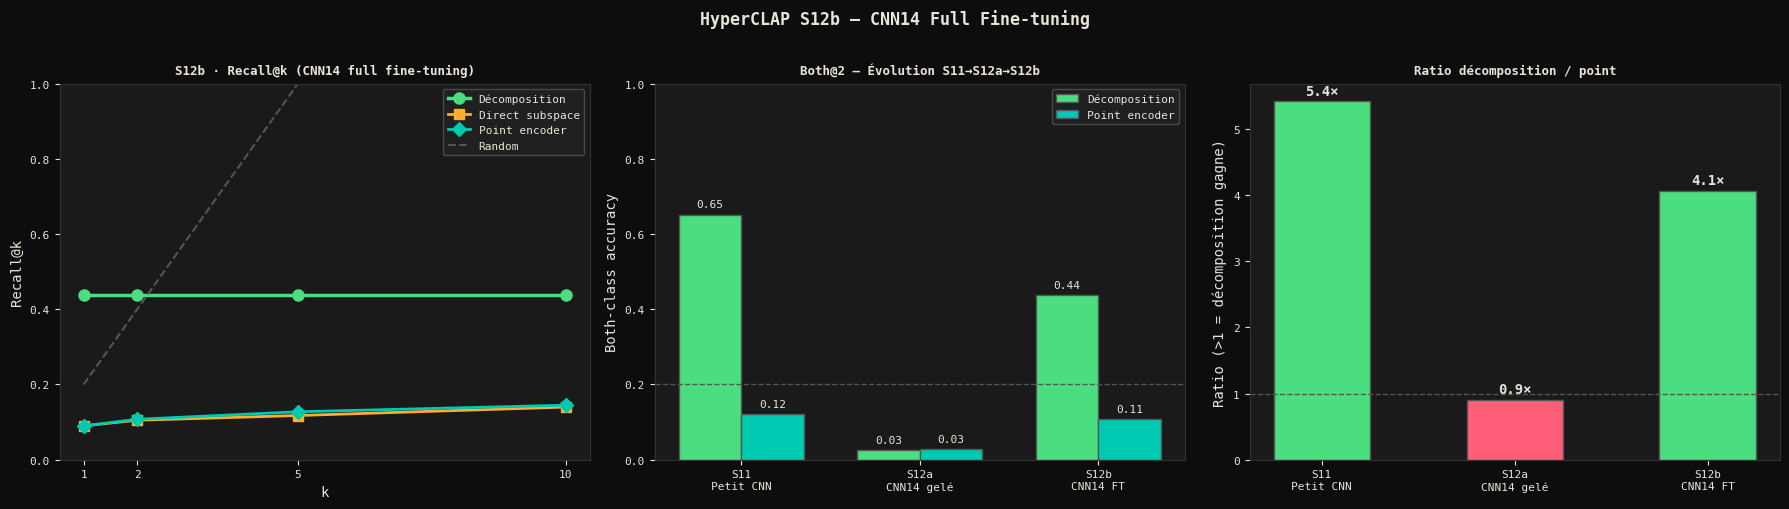

In [30]:
DARK="#0d0d0d"; LIGHT="#e8e4d9"; CYAN="#00c9b1"; AMBER="#ffad2f"
ROSE="#ff5e78"; GREEN="#4ade80"

plt.rcParams.update({
    "text.color":LIGHT,"axes.labelcolor":LIGHT,"xtick.color":LIGHT,
    "ytick.color":LIGHT,"axes.edgecolor":"#333333","font.family":"monospace"})

def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title, color=LIGHT, fontsize=9, pad=7, fontweight="bold")
    ax.tick_params(colors=LIGHT, labelsize=8); ax.spines[:].set_color("#333333")

fig, axes = plt.subplots(1, 3, figsize=(18, 5)); fig.patch.set_facecolor(DARK)

# Recall@k
ax = axes[0]; ax_style(ax, "S12b · Recall@k (CNN14 full fine-tuning)")
ax.plot(KS, [recalls[k]["decomp"] for k in KS], "o-", color=GREEN, lw=2.5, ms=8, label="Décomposition")
ax.plot(KS, [recalls[k]["direct"] for k in KS], "s-", color=AMBER, lw=2, ms=7, label="Direct subspace")
ax.plot(KS, [recalls[k]["pt"]     for k in KS], "D-", color=CYAN,  lw=2, ms=7, label="Point encoder")
ax.plot(KS, [2*k/N_CLASSES for k in KS], "--", color="#555", lw=1.5, label="Random")
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(KS); ax.set_ylim(0, 1.0)
ax.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)

# Both@2 — 3 setups
ax2 = axes[1]; ax_style(ax2, "Both@2 — Évolution S11→S12a→S12b")
setups = ["S11\nPetit CNN", "S12a\nCNN14 gelé", "S12b\nCNN14 FT"]
dv = [S11_DECOMP, S12A_DECOMP, s12b_decomp]
pv = [S11_PT,     S12A_PT,     s12b_pt]
x = np.arange(3); w = 0.35
ax2.bar(x-w/2, dv, w, color=GREEN, edgecolor="#555", label="Décomposition")
ax2.bar(x+w/2, pv, w, color=CYAN,  edgecolor="#555", label="Point encoder")
ax2.axhline(2/N_CLASSES, color="#555", ls="--", lw=1)
ax2.set_xticks(x); ax2.set_xticklabels(setups, fontsize=8)
ax2.set_ylabel("Both-class accuracy"); ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
for i_, (d, p) in enumerate(zip(dv, pv)):
    ax2.text(i_-w/2, d+0.02, f"{d:.2f}", ha="center", color=LIGHT, fontsize=8)
    ax2.text(i_+w/2, p+0.02, f"{p:.2f}", ha="center", color=LIGHT, fontsize=8)

# Ratio
ax3 = axes[2]; ax_style(ax3, "Ratio décomposition / point")
ratios = [S11_DECOMP/(S11_PT+1e-8), S12A_DECOMP/(S12A_PT+1e-8), ratio_12b]
cols   = [GREEN if r > 3 else AMBER if r > 1.5 else ROSE for r in ratios]
ax3.bar(setups, ratios, color=cols, edgecolor="#555", width=0.5)
ax3.axhline(1.0, color="#555", ls="--", lw=1)
ax3.set_ylabel("Ratio (>1 = décomposition gagne)")
for i_, val in enumerate(ratios):
    ax3.text(i_, val+0.1, f"{val:.1f}×", ha="center", color=LIGHT, fontsize=10, fontweight="bold")

fig.suptitle("HyperCLAP S12b — CNN14 Full Fine-tuning",
             color=LIGHT, fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/hyperclap_section12b.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved → hyperclap_section12b.png")
plt.show()